In [2]:
import math
import warnings
from typing import Any, Dict, Tuple

import jax
from jax import numpy as jnp

from matplotlib import pyplot as plt

from blueprint.qubits.fluxonium import Fluxonium
from blueprint.qubits.harmonic_oscillator import HarmonicOscillator
from blueprint.devices import Device
from blueprint.util.index import get_branch_inds
from blueprint.util.quantum import expectation_value

jax.config.update("jax_enable_x64", True)  # Double

In [3]:
def get_figsize(
    columns: int = 1, fig_width : float | None = None, fig_height: float | None = None, width_scale: float = 1.0, height_scale: float = 1.0
) -> Tuple[float, float]:
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    MAX_HEIGHT = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = (
            3.4 if columns == 1 else 7
        )  # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > MAX_HEIGHT:
        warnings.warn(
            "Figure height {} is too large, setting to {}"
            "inches instead".format(fig_height, MAX_HEIGHT)
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps",
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

Define the units

In [4]:
# units 
GHz = 2 * math.pi 
MHz = 2 * 1e-3 * math.pi

Create the fluxonium object

In [5]:
FLUXONIUM_LABEL: str = "fluxonium"
JOSEPHSON_ENERGY: float = 4 * GHz
CHARGING_ENERGY: float = 1 * GHz
INDUCTIVE_ENERGY: float = 1 * GHz
EXT_FLUX: float = 0.5 * 2 * math.pi
FOCK_DIM_CUT_OFF: int = 1000
QUBIT_DIM: int = 16

qubit = Fluxonium(
    label=FLUXONIUM_LABEL,
    josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    ext_flux=EXT_FLUX,
    fock_cutoff=FOCK_DIM_CUT_OFF
)

qubit.diagonalize(truncated_dim=QUBIT_DIM)

Create the resonator qubit

In [6]:
RES_LABEL: str = "resonator"
RES_FREQ: float = 7.5 * GHz
RES_IMPEDENCE: float = 50.0
RES_DIM: int = 300

charging_energy = 1 * GHz
inductive_energy = RES_FREQ ** 2 / (8 * charging_energy)

#resonator = HarmonicOscillator.from_frequency(
#    label=RES_LABEL,
#    frequency=RES_FREQ,
#    impedence=RES_IMPEDENCE,
#    dim=RES_DIM,
#)

resonator = HarmonicOscillator(
    label=RES_LABEL,
    charging_energy=charging_energy,
    inductive_energy=inductive_energy,
    dim=RES_DIM
)

Create the device consisting of the qubit-resonator system and add the coupling between the two qubits

In [7]:
COUPLING: float = 120 * MHz

device = Device((qubit, resonator))
device.add_capacative_coupling(("fluxonium", "resonator"), "coupling", COUPLING / resonator.charge_zpf)

Perform the branch analysis 

In [8]:
hamiltonian = device.get_hamiltonian()
energies, states = device.get_eigenstates()

ground_inds = jnp.argmax(jnp.abs(states[::RES_DIM]), axis=1)

raise_op = resonator.get_raise_op()
inds = get_branch_inds(states, raise_op, ground_inds)

branch_energies = energies[inds]
branches = states[:, inds]

qubit_num_op = qubit.get_number_op()
res_num_op = resonator.get_number_op()

res_populations = jnp.real(expectation_value(branches, res_num_op))
qubit_populations = jnp.real(expectation_value(branches, qubit_num_op))

res_populations = res_populations.reshape(QUBIT_DIM, RES_DIM)
qubit_populations = qubit_populations.reshape(QUBIT_DIM, RES_DIM)

Plot the results

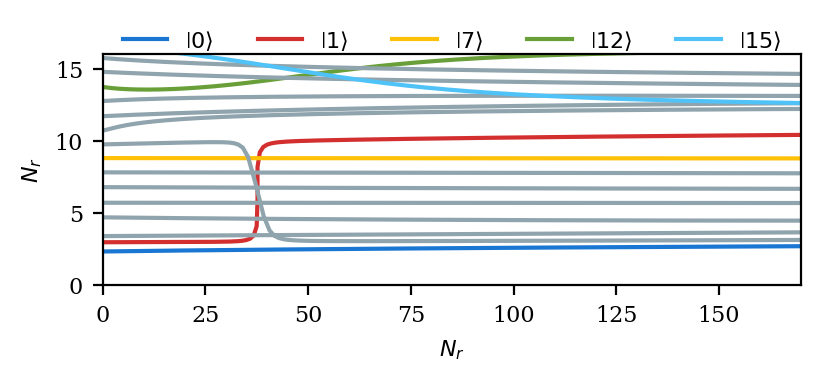

In [9]:
figsize = get_figsize(width_scale=1.25)  # Use the recommended figure size for two-column figures
rc_params = get_rc_params()  # Use the recommended rc params

highlighted_states = (0, 1, 7, 12, 15)
colors = ["#1976d2", "#d32f2f", "#ffc107", "#689f38", "#4fc3f7"]
default_color = "#90a4ae"

states = list(range(QUBIT_DIM))

with plt.rc_context(rc=rc_params):
    fig, ax = plt.subplots(figsize=figsize, sharex=True, tight_layout=True, dpi=200)

    for state in states:
        if state in highlighted_states:
            state_ind = highlighted_states.index(state)
            color = colors[state_ind]
            label = f"$\\left\\vert {{{state}}} \\right\\rangle$"
        else: 
            color = default_color
            label = None
        ax.plot(res_populations[state], qubit_populations[state], color=color, label=label)

    ax.legend(ncols=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.2))
    ax.set_xlim(0, 170)
    # ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160])
    ax.set_xlabel(r"$N_{r}$")

    ax.set_ylim(0, 16)
    # ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
    ax.set_ylabel(r"$N_{r}$")

plt.show()


In [9]:
# ! Test energies 
energies_reshaped = branch_energies.reshape(QUBIT_DIM, RES_DIM)

fluxonium_freq = energies_reshaped[1][0] - energies_reshaped[0][0]
chi = (energies_reshaped[1][1] - energies_reshaped[1][0] - energies_reshaped[0][1] + energies_reshaped[0][0]) / 2
resonator_freq = energies_reshaped[0][1] - energies_reshaped[0][0]

print(resonator_freq / GHz)
print(resonator.frequency / GHz)
print(fluxonium_freq / GHz)
print(qubit.frequency / GHz)
print(chi / MHz)

7.502023046208768
7.499999999999999
0.581502421704696
0.5818489963974276
-0.8501104902926964


In [10]:
print(energies[0:10] / GHz)

[ 0.          0.58150242  3.96882203  6.57026035  7.50202305  8.08182525
  9.86100954 11.46820413 13.22453897 14.06902305]


In [11]:
GHz = 2 * math.pi
MHz = 2 * 1e-3 * math.pi

FLUXONIUM_LABEL: str = "fluxonium"
JOSEPHSON_ENERGY: float = 4 * GHz
CHARGING_ENERGY: float = 1 * GHz
INDUCTIVE_ENERGY: float = 1 * GHz
EXT_FLUX: float = 0.5 * 2 * math.pi
FOCK_DIM_CUT_OFF: int = 1000
QUBIT_DIM: int = 16

qubit = Fluxonium(
    label=FLUXONIUM_LABEL,
    josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    ext_flux=EXT_FLUX,
    fock_cutoff=FOCK_DIM_CUT_OFF
)

# qubit.diagonalize(truncated_dim=QUBIT_DIM)
print(qubit.frequency / GHz)

cos_phi_f_bp = qubit.get_cosphi_op()
n_f_bp = qubit.get_charge_op()
phi_f_bp = qubit.get_flux_op()
hamiltonian_bp = qubit.get_hamiltonian()
eigvecs_bp = qubit.get_eigenstates()[1]
eigvals_bp = qubit.get_eigenstates()[0]

print(cos_phi_f_bp[:3, :3])

0.5818489963974276
[[ 0.49306869+0.j  0.        +0.j -0.49306869+0.j]
 [ 0.        +0.j -0.20423574+0.j  0.        +0.j]
 [-0.49306869+0.j  0.        +0.j -0.40847148+0.j]]


# TEST

In [12]:
import copy 
from qutip import *
import numpy as np
from scipy.linalg import eigh
import jax.scipy as jsc
import time 

class Fluxonium_System():
    
    def __init__(self, params):
        
        # Retrieve parameters 
        self.params = copy.deepcopy(params)

        self.dim_r = self.params['dim_r']
        self.dim_f = self.params['dim_f']
        self.dim = self.dim_f * self.dim_r

        self.Ej = self.params['Ej']
        self.Ec = self.params['Ec']
        self.El = self.params['El']
        self.flux_point = self.params['flux_point']

        self.omega_r = self.params['omega_r']
        self.eps = self.params['eps']
        self.kappa = self.params['kappa']

        self.g = self.params['g']

        self.t_max = 500 # 500 ns 
        self.tlist = np.linspace(0, self.t_max, 10000)

        # Initialize fluxonium 
        self.n_f, self.phi_f, self.cos_f, self.eigval_f, self.temp_n_f, self.temp_phi_f, self.temp_cos_f, self.H_fluxonium, self.U= self.initialize_fluxonium()

        # Fluxonium projection operators 
        self.f_projectors = [tensor(basis(self.dim_f, i) * basis(self.dim_f, i).dag(), qeye(self.dim_r)) for i in range(self.dim_f)]
        self.N_f = sum([i * P for i, P in enumerate(self.f_projectors)]) # Average fluxonium population

        # Initialize resonator 
        self.a = tensor(qeye(self.dim_f), destroy(self.dim_r))
        self.a_dag = self.a.dag()
        self.N_r = tensor(qeye(self.dim_f), num(self.dim_r))

        # Construct full Hamiltonian 
        # self.H = self.Hamiltonian()


    def initialize_fluxonium(self):
        
        Fock_basis_dim = 1000 

        b = destroy(Fock_basis_dim)
        b_dag = create(Fock_basis_dim)

        n_f = (1.j/np.sqrt(2)) * ((self.El / (8 * self.Ec))**(0.25)) * (b_dag - b)
        phi_f = (1/np.sqrt(2)) * ((8 * self.Ec / self.El)**(0.25)) * (b_dag + b)
        cos_f = phi_f.cosm()

        temp_n_f = n_f
        temp_phi_f = phi_f
        temp_cos_f = cos_f

        H_fluxonium = (4 * self.Ec * n_f**2) - (self.Ej * cos_f) + ((self.El / 2) * (phi_f + self.flux_point * (2 * np.pi) * qeye(Fock_basis_dim))**2 )

        eigval, U = eigh(H_fluxonium)

        # eigval -= eigval[0] # Shift the energies 

        print(f"fluxonium qubit frequency is: {(eigval[1] - eigval[0])/(2 * np.pi)} GHz")

        print(f"0 -> 1 transition frequency is: {(eigval[1] - eigval[0])/(2 * np.pi)} GHz")
        print(f"1 -> 2 transition frequency is: {(eigval[2] - eigval[1])/(2 * np.pi)} GHz")
        print(f"2 -> 3 transition frequency is: {(eigval[3] - eigval[2])/(2 * np.pi)} GHz")
        print(f"0 -> 3 transition frequency is: {(eigval[3] - eigval[0])/(2 * np.pi)} GHz")
        print(f"1 -> 4 transition frequency is: {(eigval[4] - eigval[1])/(2 * np.pi)} GHz")
        print(f"2 -> 5 transition frequency is: {(eigval[5] - eigval[2])/(2 * np.pi)} GHz")


        print(f"Excited state: {(eigval[1] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Second excited state: {(eigval[2] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Third excited state: {(eigval[3] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Fourth excited state: {(eigval[4] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Fifth excited state: {(eigval[5] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Sixth excited state: {(eigval[6] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Seventh excited state: {(eigval[7] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Eighth excited state: {(eigval[8] - eigval[0]) / (2 * np.pi)} GHz")
        print(f"Nineth excited state: {(eigval[9] - eigval[0]) / (2 * np.pi)} GHz")

        # Change to fluxonium eigenbasis 
        U = Qobj(U)
        n_f = U.dag() * n_f * U 
        phi_f = U.dag() * phi_f * U 
        cos_f = U.dag() * cos_f * U 

        temp_n_f_2 = n_f

        # Extract relevant dimensions 
        n_f = n_f.extract_states(range(self.dim_f))
        phi_f = phi_f.extract_states(range(self.dim_f))
        cos_f = cos_f.extract_states(range(self.dim_f))

        # Tensor up 
        n_f = tensor(n_f, qeye(self.dim_r))
        phi_f = tensor(phi_f, qeye(self.dim_r))
        cos_f = tensor(cos_f, qeye(self.dim_r))

        return n_f, phi_f, cos_f, eigval, temp_n_f, temp_phi_f, temp_cos_f, H_fluxonium, U

    def Hamiltonian(self):
        
        H_r = self.omega_r * self.a_dag * self.a 
        H_f = tensor(qdiags(self.eigval_f[:self.dim_f], 0), qeye(self.dim_r))

        H_int = -1.j * self.g * self.n_f * (self.a - self.a_dag)

        H = H_r + H_f + H_int

        H_d = -1.j * self.eps * (self.a - self.a_dag)
        H_d_coeff = 'np.sin(omega_d * t)'

        H = [H, [H_d, H_d_coeff]]

        return H 

    def Displaced_Hamiltonian(self):
        
        H_r = self.omega_r * self.a_dag * self.a 
        H_f = tensor(qdiags(self.eigval_f[:self.dim_f], 0), qeye(self.dim_r))

        H_int = -1.j * self.g * self.n_f * (self.a - self.a_dag)

        H_int2 = -1.j * self.g * self.n_f 
        H_int2_coeff = "((eps / (-4 * dressed_omega_r + 1.j * kappa)) * np.exp(1.j * dressed_omega_r * t)) - ((eps / (1.j * kappa)) * np.exp(-1.j * dressed_omega_r * t)) + (((eps / (1.j * kappa)) - (eps / (-4 * dressed_omega_r + 1.j * kappa))) * np.exp(-(1.j * dressed_omega_r + kappa/2) * t)) - np.conj(((eps / (-4 * dressed_omega_r + 1.j * kappa)) * np.exp(1.j * dressed_omega_r * t)) - ((eps / (1.j * kappa)) * np.exp(-1.j * dressed_omega_r * t)) + (((eps / (1.j * kappa)) - (eps / (-4 * dressed_omega_r + 1.j * kappa))) * np.exp(-(1.j * dressed_omega_r + kappa/2) * t)))"

        H_int3 = -(self.dressed_omega_r - self.omega_r) * self.a_dag
        H_int3_coeff = "((eps / (-4 * dressed_omega_r + 1.j * kappa)) * np.exp(1.j * dressed_omega_r * t)) - ((eps / (1.j * kappa)) * np.exp(-1.j * dressed_omega_r * t)) + (((eps / (1.j * kappa)) - (eps / (-4 * dressed_omega_r + 1.j * kappa))) * np.exp(-(1.j * dressed_omega_r + kappa/2) * t))"

        H_int4 = -(self.dressed_omega_r - self.omega_r) * self.a
        H_int4_coeff = "np.conj(((eps / (-4 * dressed_omega_r + 1.j * kappa)) * np.exp(1.j * dressed_omega_r * t)) - ((eps / (1.j * kappa)) * np.exp(-1.j * dressed_omega_r * t)) + (((eps / (1.j * kappa)) - (eps / (-4 * dressed_omega_r + 1.j * kappa))) * np.exp(-(1.j * dressed_omega_r + kappa/2) * t)))"

        H = [H_r + H_f + H_int, [H_int2, H_int2_coeff], [H_int3, H_int3_coeff], [H_int4, H_int4_coeff]]

        return H 

    def alpha_f(t, args):
        
        eps = args['eps']
        dressed_omega_r = args['dressed_omega_r']
        kappa = args['kappa']
        
        A = eps / (-4 * dressed_omega_r + 1.j * kappa)
        B = eps / (1.j * kappa)

        C = (A * np.exp(1.j * dressed_omega_r * t)) - (B * np.exp(-1.j * dressed_omega_r * t)) + ((B - A) * np.exp(-(1.j * dressed_omega_r + kappa/2) * t))

        return C 

    def branch_analysis(self, max_f, max_r):
        
        """
            Branch analysis for the fluxonium
        """

        branch_analysis_start_time = time.time()

        H_r = self.omega_r * self.a_dag * self.a 
        H_f = tensor(qdiags(self.eigval_f[:self.dim_f], 0), qeye(self.dim_r))
        H_int = -1.j * self.g * self.n_f * (self.a - self.a_dag)
        H = H_r + H_f + H_int

        E, Eigvecs = H.eigenstates()

        return E, Eigvecs, H, H_int

        # Building the matrices which will be used to determine the different branches 
        branch_criteria_matrix = copy.deepcopy(self.a_dag.transform(Eigvecs).full())

        # Turn all the branch criteria matrix elements to their magnitude 
        for lambda_idx in range(self.dim):
            for n_idx in range(self.dim):
                branch_criteria_matrix[lambda_idx, n_idx] = np.abs(branch_criteria_matrix[lambda_idx, n_idx]) 
    
        # Initializing branches and branch index 
        self.branches_idx = [[] for l in range(max_f)] # Maximum branch number is max_t 
        self.E_branches = [[] for l in range(max_f)]
        self.branches = [[] for l in range(max_f)]

        # Initialise the first set of branches where n = 0 
        for i_f in range(max_f):
            
            # First state in branch has largest overlap with bare |i_f, 0>
            self.branches_idx[i_f].append(np.argmax([np.abs(state[i_f * self.dim_r])**2 for state in Eigvecs]))

            # Once chosen, need to set the branch matrix criteria to zero so that it doesn't get chosen again 
            branch_criteria_matrix[self.branches_idx[i_f][0]] = 0 

        n_r = 0 
        while n_r <= max_r:
            
            # print("Performing branch analysis on resonator number: {}/{}".format(n_r, max_r), flush=True)

            for i_f in range(max_f):

                # Recursive definition of the branch 
                self.branches_idx[i_f].append(np.argmax(branch_criteria_matrix[:, self.branches_idx[i_f][n_r]]))

                # Need to make sure that branch matrix criteria doesn't get chosen again by setting it to zero 
                branch_criteria_matrix[self.branches_idx[i_f][n_r+1]] = 0
            
            n_r += 1         

        # Using the branch indexes we find the correct eigenvectors and energies 
        for i_f in range(max_f):
            for n in range(max_r):
                self.E_branches[i_f].append(E[self.branches_idx[i_f][n]])
                self.branches[i_f].append(Eigvecs[self.branches_idx[i_f][n]])

        # Compute <n_r> and <N_t> 
        self.branches_N_r_avg = [[] for l in range(max_f)]
        self.branches_N_f_avg = [[] for l in range(max_f)]

        for i_f in range(max_f):
            for state in self.branches[i_f]:
                self.branches_N_r_avg[i_f].append(np.real(state.overlap(self.N_r * state)))
                self.branches_N_f_avg[i_f].append(np.real(state.overlap(self.N_f * state)))

        # Compute chi and dressed frequencies 
        self.chi = (self.E_branches[1][1] - self.E_branches[1][0] - self.E_branches[0][1] - self.E_branches[0][0]) / 2 # Numerically calculated chi shift 
        self.dressed_omega_q = self.E_branches[1][0] - self.E_branches[0][0]
        self.dressed_omega_r = (self.E_branches[1][1] + self.E_branches[0][1] - self.dressed_omega_q) / 2

        print('chi shift: ', 1000 * self.chi / (2 * np.pi), "MHz")
        print("dressed omega_q: ", self.dressed_omega_q / (2 * np.pi), "GHz")
        print("dressed omega_r: ", self.dressed_omega_r / (2 * np.pi), "GHz")

        # Print time it took to do branch analysis 
        print(f"Finished branch analysis in {time.time() - branch_analysis_start_time} seconds")

In [13]:
GHz = 1 
MHz = 1e-3 * GHz

params = {
    'Ec':1 * (2 * np.pi) * GHz,
    'Ej':4 * (2 * np.pi) * GHz,
    'El':1 * (2 * np.pi) * GHz,
    'omega_r':7.5 * (2 * np.pi) * GHz,
    'g': 120 * (2 * np.pi) * MHz,
    'kappa': 15 * (2 * np.pi) * MHz,
    'eps': 30 * (2 * np.pi) * MHz, 
    'flux_point': 0.5, # Corresponding to a half flux sweet spot
    'dim_f': 16,
    'dim_r': 300
}

# Generate the system 
System = Fluxonium_System(params=params)
print(System.temp_cos_f[:3, :3])

fluxonium qubit frequency is: 0.5818489963974338 GHz
0 -> 1 transition frequency is: 0.5818489963974338 GHz
1 -> 2 transition frequency is: 3.388586558452058 GHz
2 -> 3 transition frequency is: 2.604052917313782 GHz
0 -> 3 transition frequency is: 6.574488472163274 GHz
1 -> 4 transition frequency is: 9.282624239791845 GHz
2 -> 5 transition frequency is: 9.258651761593912 GHz
Excited state: 0.5818489963974338 GHz
Second excited state: 3.9704355548494923 GHz
Third excited state: 6.574488472163274 GHz
Fourth excited state: 9.86447323618928 GHz
Fifth excited state: 13.229087316443403 GHz
Sixth excited state: 16.64368296697188 GHz
Seventh excited state: 19.979068202851384 GHz
Eighth excited state: 23.1374442970239 GHz
Nineth excited state: 26.029204950073506 GHz
[[ 0.49306869+0.j  0.        +0.j -0.49306869+0.j]
 [ 0.        +0.j -0.20423574+0.j  0.        +0.j]
 [-0.49306869+0.j  0.        +0.j -0.40847148+0.j]]


In [14]:
print(np.allclose(cos_phi_f_bp, System.temp_cos_f))
print(np.allclose(n_f_bp, System.temp_n_f))
print(np.allclose(phi_f_bp, System.temp_phi_f))

# print(System.U.full())

print(System.n_f[0:3, 300:301])

print(qubit.frequency / (2 * np.pi))
print(0.5818489963974338)


True
True
True
[[0.-0.15499096j]
 [0.+0.j        ]
 [0.+0.j        ]]
0.5818489963974276
0.5818489963974338


In [15]:
print(np.allclose(hamiltonian_bp, System.H_fluxonium.full()))
print(np.allclose(eigvecs_bp, System.U.full()))
print(np.allclose(eigvals_bp, System.eigval_f))

print(np.allclose(System.H_fluxonium * System.U[:,0], System.eigval_f * System.U[:,0]))
print(np.allclose(hamiltonian_bp @ eigvecs_bp[:,0], eigvals_bp @ eigvecs_bp[:,0], atol=1e-3))

True
False
False
False
False


In [16]:
import jax.scipy as jsc

A, B = jsc.linalg.eigh(hamiltonian_bp)

In [17]:
print(np.allclose(hamiltonian_bp @ B[:, 16], A[16] * B[:,16]))

True


In [18]:
E_full, Eigvecs_full, H_full, H_int_full = System.branch_analysis(16, 16)

In [19]:
print(np.allclose(hamiltonian, H_full.full()))

False


In [20]:
print(System.branch_analysis(2, 2))

(array([1.35475183e+01, 1.72012058e+01, 3.84843625e+01, ...,
       1.43418341e+04, 1.43614022e+04, 1.43690586e+04]), array([Quantum object: dims = [[16, 300], [1, 1]], shape = (4800, 1), type = ket
       Qobj data =
       [[ 9.99992280e-01]
        [ 0.00000000e+00]
        [-1.74985573e-05]
        ...
        [ 0.00000000e+00]
        [ 0.00000000e+00]
        [ 0.00000000e+00]]                                                      ,
       Quantum object: dims = [[16, 300], [1, 1]], shape = (4800, 1), type = ket
       Qobj data =
       [[0.        ]
        [0.00268797]
        [0.        ]
        ...
        [0.        ]
        [0.        ]
        [0.        ]]                                                           ,
       Quantum object: dims = [[16, 300], [1, 1]], shape = (4800, 1), type = ket
       Qobj data =
       [[-6.64265957e-06]
        [ 0.00000000e+00]
        [-3.38394778e-06]
        ...
        [ 0.00000000e+00]
        [ 0.00000000e+00]
        [ 0.00000

In [21]:
print(np.allclose(device.get_int_hamiltonian(), H_int_full.full()))

print(device.get_int_hamiltonian()[600:610, 600:610])
print(H_int_full.full()[600:610, 600:610])

print(jnp.nonzero(device.get_int_hamiltonian()))
print(device.get_int_hamiltonian()[0,301])
print(H_int_full.full()[0,301])


False
[[ 0.00000000e+00+0.j -3.13908165e-17+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 3.13908165e-17+0.j  0.00000000e+00+0.j -4.43933184e-17+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  4.43933184e-17+0.j  0.00000000e+00+0.j
  -5.43704890e-17+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  5.43704890e-17+0.j
   0.00000000e+00+0.j -6.27816330e-17+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   6.27816330e-17+0.j  0.00000000e+00+0.j -7.01919995e-17+0.j
   0.00000000e+00+0.j  0.00000000e

In [22]:
print(resonator.charge_zpf)

print(resonator._el)
print(resonator._ec)

0.6846531968814576
44.17864669110646
6.283185307179586


In [23]:
print(qubit.get_charge_op()[0,1])

-0.42044820762685725j


In [24]:
qubit.diagonalize(truncated_dim=QUBIT_DIM)
print(qubit.frequency / (2 * np.pi))

cos_phi_f_bp = qubit.get_cosphi_op()
n_f_bp = qubit.get_charge_op()
phi_f_bp = qubit.get_flux_op()
hamiltonian_bp = qubit.get_hamiltonian()
eigvecs_bp = qubit.get_eigenstates()[1]
eigvals_bp = qubit.get_eigenstates()[0]

KeyboardInterrupt: 

In [ ]:
print(np.allclose(n_f_bp, (System.U.dag() * System.temp_n_f * System.U).extract_states(range(16)).full()))

n_f_eigenbasis = (System.U.dag() * System.temp_n_f * System.U).extract_states(range(16)).full()

C = jnp.array(System.U.full())
D = jnp.conj(C.T) @ qubit._get_charge_op(include_fluctuations=True) @ C

n_f_eigenbasis_with_bp = (Qobj(np.array(eigvecs_bp)).dag() * System.temp_n_f * Qobj(np.array(eigvecs_bp))).extract_states(range(16)).full()

print(n_f_bp[:3, :3])
print(n_f_eigenbasis[:3, :3])

False


TypeError: dot_general requires contracting dimensions to have the same shape, got (1000,) and (16,).

In [ ]:
print(C.shape)
print(qubit._get_charge_op(include_fluctuations=True).shape)

(1000, 1000)
(16, 16)
